## Middleware
Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

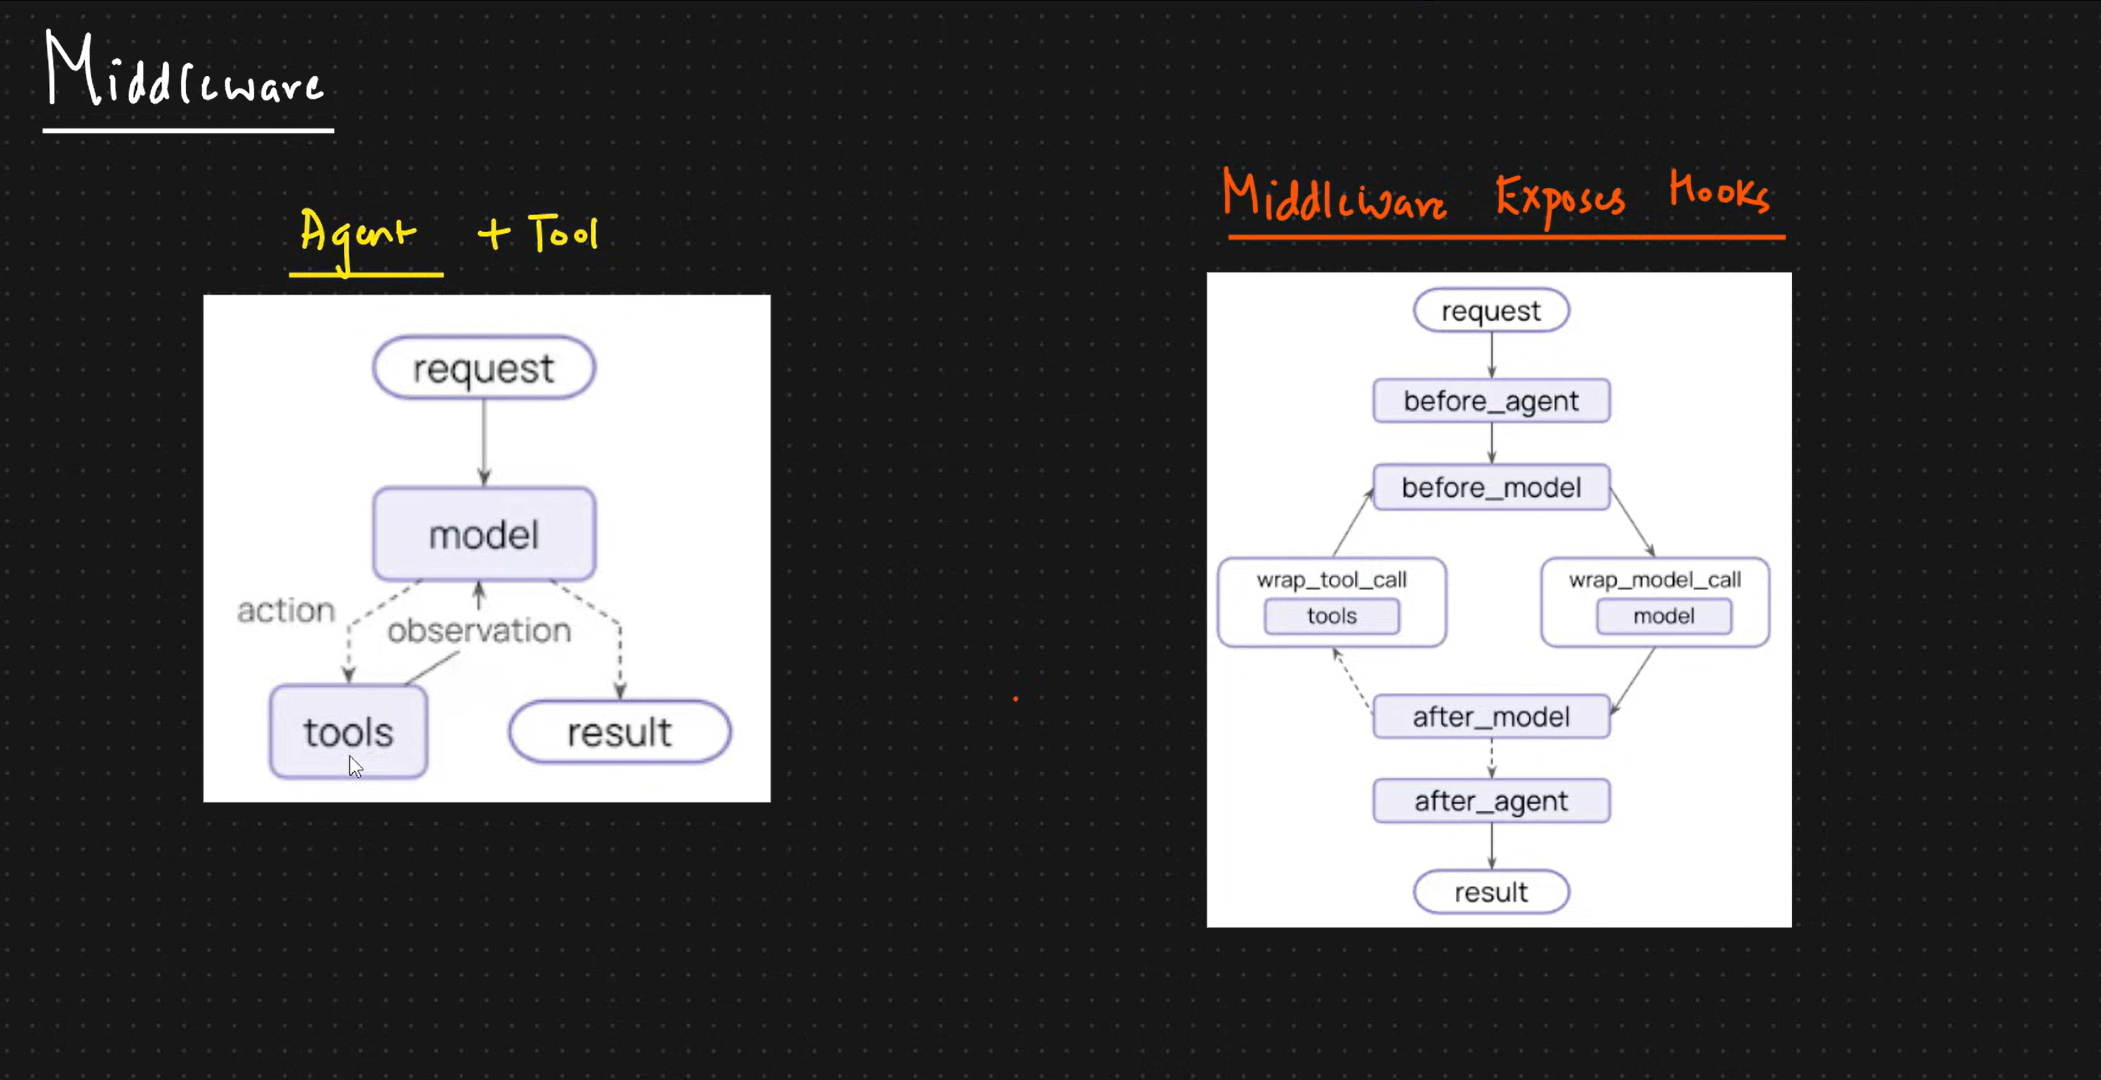

In [14]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

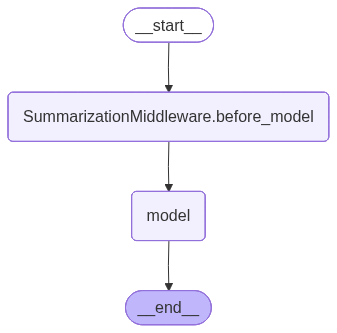

In [20]:
# step 1: create agent
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(model = "gemini-2.0-flash-lite")

## agent with Message_based summarization

agent = create_agent(
    model = model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model = model,
            trigger = ("messages",10),  # summarize when messages length > 10
            keep = ("messages",4)       # Keep the last 4 messages 
        )
    ]
)
agent

In [16]:
# create a thread for unique session id
config = {"configurable":{"thread_id":"test1"}}

In [9]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='0d387f79-51e0-4db6-bdc7-290e8545ed3b'), AIMessage(content='2 + 2 = 4', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5f15-7c64-7840-885a-370598b19a32-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 27, 'total_tokens': 35, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 20}})]}
Messages: 2
Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='0d387f79-51e0-4db6-bdc7-290e8545ed3b'), AIMessage(content='2 + 2 = 4', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5f15-7c64-7840-885a-370598b19a32-0', tool_c

### Using Token Size
Let's see this implemant with respect to tool

In [17]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens.""" 
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent = create_agent(
    model=model,
    tools = [search_hotels],
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model = model,
            trigger = ("tokens",550),
            keep = ("tokens",200)
        )
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # 4 chars = 1 token

In [18]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config = config
    )

    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~94 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='c25529d8-1e9f-4271-8c42-19ce40a7dd55'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_hotels', 'arguments': '{"city": "Paris"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e659c-03fc-7ba3-ab9a-6ed0386c22d5-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': '9b5bed04-2c00-4b1b-a41c-51f20542e7d3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 15, 'total_tokens': 63, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='Hotels in Paris:\n    1. Grand Hotel - 5 star, $350/night, spa, pool, gym\n    2. City Inn - 4 star, $180/night, business center\n    3. Budget Stay - 3 star, $75/night, free wifi', name='search_hotels', id='bb39ab72-7a49-48

### Using Fraction

In [19]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens.""" 
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent = create_agent(
    model=model,
    tools = [search_hotels],
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model = model,
            trigger = ("fraction", 0.005), # 0.5% = ~640 tokens
            keep = ("fraction", 0.002)     # 0.2% = ~256 tokens
        )
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # 4 chars = 1 token

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config = config
    )

    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000 # content
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(f"{(response['messages'])}")


Paris: ~92 tokens (0.0719%), 4 msgs
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='b8894dbe-b2a1-48e1-903a-2c2ee5814a75'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_hotels', 'arguments': '{"city": "Paris"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e659d-859d-7073-9900-6d98f8ba59ce-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': '2f6b4072-5bbc-49e3-9a56-8877d6a81296', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 15, 'total_tokens': 63, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='Hotels in Paris:\n    1. Grand Hotel - 5 star, $350/night, spa, pool, gym\n    2. City Inn - 4 star, $180/night, business center\n    3. Budget Stay - 3 star, $75/night, free wifi', name='search_hotels', id='952c68b6-9

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 12.542868513s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerM

### Human In the Loop MiddleWare
Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [47]:
import os
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
model = init_chat_model("groq:llama-3.1-8b-instant")
model

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001C1398AEE90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001C1398AE350>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [25]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [26]:
agent=create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)

In [27]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [28]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='67326522-a7dd-453f-bb49-4d2c27518c9d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'y2xsgdt36', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 309, 'total_tokens': 341, 'completion_time': 0.028617928, 'completion_tokens_details': None, 'prompt_time': 0.024140126, 'prompt_tokens_details': None, 'queue_time': 0.055187734, 'total_time': 0.052758054}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e65a5-8056-76b3-99d6-9c90b2263761-0', tool_calls=[{'name': 'send_email_tool', 'args': {'body

In [29]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: Email sent to john@test.com with subject 'Hello'


In [30]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='67326522-a7dd-453f-bb49-4d2c27518c9d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'y2xsgdt36', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 309, 'total_tokens': 341, 'completion_time': 0.028617928, 'completion_tokens_details': None, 'prompt_time': 0.024140126, 'prompt_tokens_details': None, 'queue_time': 0.055187734, 'total_time': 0.052758054}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e65a5-8056-76b3-99d6-9c90b2263761-0', tool_calls=[{'name': 'send_email_tool', 'args': {'body

### Reject

In [48]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [49]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [50]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: 


In [51]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='9cb8a264-1536-425b-b9c3-106726748f0c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '49sfzfgck', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 309, 'total_tokens': 341, 'completion_time': 0.028468777, 'completion_tokens_details': None, 'prompt_time': 0.023931999, 'prompt_tokens_details': None, 'queue_time': 0.049252204, 'total_time': 0.052400776}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e65b2-96b2-75a1-ab32-0a1eb57008d1-0', tool_calls=[{'name': 'send_email_tool', 'args': {'body

### Editing

In [35]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [36]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [37]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='d8c422b0-7de3-4035-bfb6-4be553c98435'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '92s2drrt9', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 307, 'total_tokens': 337, 'completion_time': 0.041838478, 'completion_tokens_details': None, 'prompt_time': 0.021529334, 'prompt_tokens_details': None, 'queue_time': 0.157512678, 'total_time': 0.063367812}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e65ac-be06-7f50-a544-91879079d82f-0', tool_calls=[{'name': 'send_email_tool', 'args': {'body': 'Hello', 

In [38]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: 


In [39]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='d8c422b0-7de3-4035-bfb6-4be553c98435'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '92s2drrt9', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 307, 'total_tokens': 337, 'completion_time': 0.041838478, 'completion_tokens_details': None, 'prompt_time': 0.021529334, 'prompt_tokens_details': None, 'queue_time': 0.157512678, 'total_time': 0.063367812}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e65ac-be06-7f50-a544-91879079d82f-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'args